In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize

# Load All Data

In [3]:
try:
    # Load Definitions
    list_exp = pd.read_csv('list_exp', index_col=0)
    list_exp.columns = ['Days']

    list_mny = pd.read_csv('list_mny', index_col=0)
    list_mny.columns = ['Moneyness']

    # Load Market Backbone
    St_df = pd.read_csv('St_df', index_col=0, parse_dates=True)
    fwd_df = pd.read_csv('fwd_df', index_col=0, parse_dates=True)
    discount_df = pd.read_csv('discount_df', index_col=0, parse_dates=True)

    # Load Full Option Data
    # low_memory=False handles mixed types. We parse dates manually for speed/safety.
    print("Loading full op_df (this may take 1-2 minutes)...")
    op_df = pd.read_csv('op_df', index_col=0, low_memory=False)
    op_df['date'] = pd.to_datetime(op_df['date'])
    print(f"Loaded op_df with {len(op_df)} rows.")

except Exception as e:
    print(f"Error loading data: {e}")

Loading full op_df (this may take 1-2 minutes)...
Loaded op_df with 13635847 rows.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

clean_df = op_df[op_df['cp_flag'] == 'C'].copy()
clean_df['date'] = pd.to_datetime(clean_df['date'])
clean_df['exdate'] = pd.to_datetime(clean_df['exdate'])
clean_df['maturity_days'] = (clean_df['exdate'] - clean_df['date']).dt.days

tenors = np.array([0, 7, 14, 30, 60, 90, 180, 350])

def interpolate_column(target_df, grid_df, col_name):
    valid_dates = target_df['date'].unique()
    grid_subset = grid_df.loc[grid_df.index.isin(valid_dates)]

    interp_map = {}
    for d, row in grid_subset.iterrows():
        interp_map[d] = interp1d(tenors, row.values, kind='linear', fill_value="extrapolate")

    results = np.zeros(len(target_df))
    target_dates = target_df['date'].values
    target_T = target_df['maturity_days'].values

    for d in np.unique(target_dates):
        if d in interp_map:
            mask = (target_dates == d)
            results[mask] = interp_map[d](target_T[mask])
    return results

clean_df['fwd_price'] = interpolate_column(clean_df, fwd_df, 'fwd_df')

clean_df['discount'] = interpolate_column(clean_df, discount_df, 'discount_df')


clean_df['spread'] = (clean_df['best_offer'] - clean_df['best_bid']).abs()
clean_df['midP'] = (clean_df['best_offer'] + clean_df['best_bid']) / 2
clean_df['spread_rel'] = clean_df['spread'] / clean_df['midP'].replace(0, np.nan)

mask_neg_spread = clean_df['best_offer'] <= clean_df['best_bid']
print(f"Negative/Zero Spread Rows: {mask_neg_spread.sum()} (Dropping these as errors)")
clean_df = clean_df[~mask_neg_spread]

cols_to_keep = ['date', 'exdate', 'strike', 'spread', 'spread_rel', 'volume',
                'fwd_price', 'discount', 'midP', 'maturity_days', 'Spot', 'best_bid', 'best_offer']
final_df = clean_df[cols_to_keep].copy()

print(f"Final Base DataFrame: {len(final_df):,} rows")

Negative/Zero Spread Rows: 15 (Dropping these as errors)
Final Base DataFrame: 6,818,138 rows


In [5]:
print("\n" + "="*60)
print("APPLYING VOLUME FILTER (>= 10 Contracts)")
print("="*60)

print(f"Row count before filter: {len(final_df):,}")

# 1. Apply the Filter
# We keep only rows where volume is 10 or greater
mask_liquid = (final_df['volume'] >= 10) & (final_df['maturity_days'] > 0)
final_df = final_df[mask_liquid].copy()

# 2. Verify Impact
print(f"Row count after filter:  {len(final_df):,}")
print(f"Dropped rows:            {mask_liquid.shape[0] - mask_liquid.sum():,}")

# 3. Sanity Check on Remaining Data
print("\n[Sanity Check on Survivors]")
print(final_df[['volume', 'spread_rel', 'midP']].describe().round(4))


APPLYING VOLUME FILTER (>= 10 Contracts)
Row count before filter: 6,818,138
Row count after filter:  913,073
Dropped rows:            5,905,065

[Sanity Check on Survivors]
            volume   spread_rel         midP
count  913073.0000  913073.0000  913073.0000
mean      720.8249       0.2311      42.5616
std      2248.8183       0.4470     128.2660
min        10.0000       0.0005       0.0250
25%        25.0000       0.0274       1.5750
50%        84.0000       0.0571      11.1500
75%       403.0000       0.1714      40.8500
max     82155.0000       2.0000    3092.6000


In [6]:
final_df.columns

Index(['date', 'exdate', 'strike', 'spread', 'spread_rel', 'volume',
       'fwd_price', 'discount', 'midP', 'maturity_days', 'Spot', 'best_bid',
       'best_offer'],
      dtype='object')

In [7]:
# Data Aggregation

def weighted_avg(x):
    v = x['volume']
    p = x['midP']
    return (p * v).sum() / v.sum()

print("Aggregating date-wise")

# A. Group by Unique Contract
g = final_df.groupby(['date', 'exdate', 'strike'])

# B. Perform Aggregation
agg_spec = {
    'volume': 'sum',
    'spread': 'mean',
    'best_bid': 'mean',
    'best_offer': 'mean',
    'fwd_price': 'first',
    'discount': 'first',
    'maturity_days': 'first',
    'Spot': 'first'
}

# Apply standard aggregations
df_agg = g.agg(agg_spec)

# Apply Weighted Average for midP separately
df_agg['midP'] = final_df.groupby(['date', 'exdate', 'strike']).apply(weighted_avg)

# C. Cleanup & Recalculate Relative Spread
df_agg = df_agg.reset_index()
df_agg['spread_rel'] = df_agg['spread'] / df_agg['midP']

print(f"Original Rows:   {len(final_df):,}")
print(f"Unique Rows: {len(df_agg):,} (Rows after aggregation)")

# BUILD THE DICTIONARY
print("\nBuilding Dictionary of Daily Surfaces...")

surface_dict = {}
# Group by date and iterate
for date_val, daily_data in df_agg.groupby('date'):
    # Sort by Expiry (Time) then Strike (Space)
    sorted_surface = daily_data.sort_values(by=['exdate', 'strike']).reset_index(drop=True)
    surface_dict[date_val] = sorted_surface

print(f"Dictionary ready with {len(surface_dict)} unique dates.")

# VERIFICATION
sample_date = list(surface_dict.keys())[5]
print(f"\n[Sample Structure: {sample_date.date()}]")
print(surface_dict[sample_date][['exdate', 'maturity_days', 'strike', 'midP', 'volume']].head())

Aggregating date-wise


/var/folders/2b/p3b4yjy93yzb0zcnk4s0f9880000gn/T/ipykernel_12261/60812347.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_agg['midP'] = final_df.groupby(['date', 'exdate', 'strike']).apply(weighted_avg)


Original Rows:   913,073
Unique Rows: 913,073 (Rows after aggregation)

Building Dictionary of Daily Surfaces...
Dictionary ready with 1762 unique dates.

[Sample Structure: 2013-01-09]
      exdate  maturity_days  strike   midP  volume
0 2013-01-11              2  1430.0  30.40      17
1 2013-01-11              2  1435.0  25.55      12
2 2013-01-11              2  1445.0  16.25      13
3 2013-01-11              2  1450.0  11.85     669
4 2013-01-11              2  1455.0   8.20     685


In [8]:
import pandas as pd
import numpy as np
import bisect
from scipy.interpolate import interp1d

# ==========================================
# 0. HELPER: BOUNDS CALCULATION (STRIKE ONLY)
# ==========================================
def get_moussa_bounds_strike_only(A_K, A_C, k_target):
    """
    Calculates Lower and Upper bounds based ONLY on the current Convex Hull.
    Disables the Calendar Floor to prevent outlier propagation.
    """
    pos = bisect.bisect_right(A_K, k_target)
    idx_L = pos - 1
    idx_R = pos

    k_L, c_L = A_K[idx_L], A_C[idx_L]

    has_right = idx_R < len(A_K)
    if has_right:
        k_R, c_R = A_K[idx_R], A_C[idx_R]
    else:
        k_R, c_R = None, None

    # --- UPPER BOUND ---
    if has_right:
        slope_chord = (c_R - c_L) / (k_R - k_L)
        upper_bound = c_L + slope_chord * (k_target - k_L)
    else:
        # Flat extrapolation (Monotonicity)
        upper_bound = c_L

    # --- LOWER BOUND ---
    if idx_L == 0:
        slope_prev = -1.0
    else:
        k_LL, c_LL = A_K[idx_L - 1], A_C[idx_L - 1]
        slope_prev = (c_L - c_LL) / (k_L - k_LL)

    strike_lower_bound = c_L + slope_prev * (k_target - k_L)

    # Strictly enforce 0 floor
    lower_bound = max(0.0, strike_lower_bound)

    return lower_bound, upper_bound

# ==========================================
# 1. MOUSSA FILTER LOGIC
# ==========================================
def moussa_filter_expiry_robust(df, lambda_param=0.0):
    df = df.copy()

    # 1. HARD PRE-FILTERING (Crucial for Hull Stability)
    # Drop Bids=0 (Worthless/Noise)
    df = df[df['best_bid'] > 0].copy()

    # Drop Crazy Normalized Prices (C_norm > 1.0 implies Price > Fwd*Disc which is impossible)
    # We define norm factor first
    norm_factor = df['discount'] * df['fwd_price']
    df['C_norm'] = df['midP'] / norm_factor
    df['K_norm'] = df['strike'] / df['fwd_price']

    # Filter insane values (likely bad Fwd/Disc data)
    df = df[df['C_norm'] <= 1.01].copy()

    if df.empty: return df

    # 2. SMART SORTING
    dist_from_atm = (df['K_norm'] - 1).abs()
    # Rank: High Volume, Near ATM, Tight Spread
    df['liquidity_score'] = df['volume'] / (dist_from_atm + 0.1)
    df = df.sort_values(by=['liquidity_score', 'spread_rel'], ascending=[False, True])

    # 3. INITIALIZE HULL
    A_K = [0.0]
    A_C = [1.0]

    results = {}

    for idx, row in df.iterrows():
        curr_k = row['K_norm']
        curr_c = row['C_norm']

        # Calculate Bounds (Strike Only)
        lb, ub = get_moussa_bounds_strike_only(A_K, A_C, curr_k)

        # Safety Clamp (Just in case)
        if lb > ub: lb = ub

        TOL = 1e-6

        if (curr_c >= lb - TOL) and (curr_c <= ub + TOL):
            final_c = curr_c
            changed = False
        else:
            changed = True
            if curr_c < lb:
                final_c = lb + lambda_param * (ub - lb)
            else:
                final_c = ub + (1 - lambda_param) * (ub - lb)

            final_c = np.clip(final_c, 0.0, 1.0)

        results[idx] = (final_c, changed)

        # Add to Hull if unique
        insert_pos = bisect.bisect_left(A_K, curr_k)
        if insert_pos < len(A_K) and abs(A_K[insert_pos] - curr_k) < 1e-9:
            pass # Duplicate K, skip update to preserve the "more liquid" anchor
        else:
            A_K.insert(insert_pos, curr_k)
            A_C.insert(insert_pos, final_c)

    # Map results
    df['moussa_C_norm'] = [results.get(i, (np.nan, False))[0] for i in df.index]
    df['is_changed'] = [results.get(i, (np.nan, False))[1] for i in df.index]

    # Denormalize
    df['moussa_price'] = df['moussa_C_norm'] * norm_factor

    return df

# ==========================================
# 2. EXECUTION LOOP
# ==========================================
print("="*60)
print("STARTING ROBUST MOUSSA FILTER (STRIKE DIMENSION ONLY)")
print("="*60)

moussa_filtered_surface_dict = {}

total_rows = 0
changed_rows = 0
max_diff = 0.0
sum_sq_diff = 0.0

LAMBDA = 0.01

for date_val, surface_df in surface_dict.items():

    expiries = sorted(surface_df['exdate'].unique())
    filtered_chunks = []

    for expiry in expiries:
        expiry_mask = surface_df['exdate'] == expiry
        expiry_df = surface_df[expiry_mask].copy()

        # Run Robust Filter (No Calendar Propagation)
        clean_expiry_df = moussa_filter_expiry_robust(expiry_df, lambda_param=LAMBDA)

        if not clean_expiry_df.empty:
            filtered_chunks.append(clean_expiry_df)

    if filtered_chunks:
        full_date_df = pd.concat(filtered_chunks)

        # Stats
        diff = (full_date_df['midP'] - full_date_df['moussa_price']).abs()
        n_changed = full_date_df['is_changed'].sum()

        total_rows += len(full_date_df)
        changed_rows += n_changed
        max_diff = max(max_diff, diff.max())
        sum_sq_diff += (diff**2).sum()

        moussa_filtered_surface_dict[date_val] = full_date_df

# ==========================================
# 3. REPORT
# ==========================================
if total_rows > 0:
    pct_changed = (changed_rows / total_rows) * 100
    rmse = np.sqrt(sum_sq_diff / total_rows)
    print("\n[FILTERING STATISTICS]")
    print(f"Total Quotes Processed: {total_rows:,}")
    print(f"Quotes Adjusted:        {changed_rows:,} ({pct_changed:.2f}%)")
    print(f"Max Price Adjustment:   ${max_diff:.4f}")
    print(f"RMSE of Adjustment:     ${rmse:.4f}")

    if pct_changed < 5.0 and max_diff < 50.0:
        print("\n✅ SUCCESS: Filter is behaving rationally.")
    else:
        print("\n⚠️ WARNING: Adjustments still seem high. Check Raw Data Quality.")
else:
    print("No data remained.")

STARTING ROBUST MOUSSA FILTER (STRIKE DIMENSION ONLY)

[FILTERING STATISTICS]
Total Quotes Processed: 874,266
Quotes Adjusted:        68,487 (7.83%)
Max Price Adjustment:   $52.5778
RMSE of Adjustment:     $0.2940

⚠️ WARNING: Adjustments still seem high. Check Raw Data Quality.


In [9]:
next(iter(moussa_filtered_surface_dict.items()))

(Timestamp('2013-01-02 00:00:00'),
           date     exdate  strike  volume  spread  best_bid  best_offer  \
 16  2013-01-02 2013-01-04  1465.0   10884    0.20      3.20        3.40   
 17  2013-01-02 2013-01-04  1470.0    9270    0.20      1.65        1.85   
 18  2013-01-02 2013-01-04  1475.0    8489    0.10      0.75        0.85   
 13  2013-01-02 2013-01-04  1450.0    7760    0.70     12.20       12.90   
 15  2013-01-02 2013-01-04  1460.0    6706    0.50      5.40        5.90   
 ..         ...        ...     ...     ...     ...       ...         ...   
 281 2013-01-02 2014-12-20  2250.0      48    0.50      1.25        1.75   
 282 2013-01-02 2015-12-19  1450.0     370   11.80    159.10      170.90   
 283 2013-01-02 2015-12-19  1600.0     450    7.70     99.70      107.40   
 284 2013-01-02 2015-12-19  2000.0     350    6.10     17.40       23.50   
 285 2013-01-02 2015-12-19  2500.0      11    0.35      2.65        3.00   
 
        fwd_price  discount  maturity_days         

In [10]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

class OptionSurfaceData:
    def __init__(self, dataframe, spot_price=None):
        """
        Ingests the specific DataFrame structure provided by the user.
        """
        self.df = dataframe.copy()

        # 1. Filter useful columns
        # We need Strike (K), Maturity (T), and Price (C)
        self.df = self.df[['strike', 'maturity_days', 'moussa_price']].copy()

        # 2. Get Spot Price (S0) for normalization
        # If not provided, we can infer it roughly or take from the 'Spot' column if it exists in the raw data
        # Based on your data, 'Spot' is a column. We take the mean (should be constant for one date)
        if spot_price is None:
            if 'Spot' in dataframe.columns:
                self.spot = dataframe['Spot'].mean()
            else:
                raise ValueError("Spot price not found. Please provide it.")
        else:
            self.spot = spot_price

        # 3. Normalize Inputs (Crucial for Neural Net Stability)
        # K_norm = Strike / Spot
        self.df['K_norm'] = self.df['strike'] / self.spot

        # T_norm = Days / 365
        self.df['T_norm'] = self.df['maturity_days'] / 365.0

        # C_norm = Price / Spot
        self.df['C_norm'] = self.df['moussa_price'] / self.spot

        # 4. Convert to PyTorch Tensors
        # x_0 = Convex Input (Strike)
        self.x_strike = torch.tensor(self.df['K_norm'].values, dtype=torch.float32).unsqueeze(1)

        # t_0 = Monotonic Input (Time)
        self.t_time = torch.tensor(self.df['T_norm'].values, dtype=torch.float32).unsqueeze(1)

        # y = Target (Price)
        self.y_price = torch.tensor(self.df['C_norm'].values, dtype=torch.float32).unsqueeze(1)

    def get_tensors(self):
        return self.x_strike, self.t_time, self.y_price

    def denormalize_price(self, normalized_price_tensor):
        """Convert model output back to dollar price"""
        return normalized_price_tensor * self.spot

# Example Usage with your dictionary item:
# key = Timestamp('2013-01-02 00:00:00')
# df = my_dictionary[key]
# data = OptionSurfaceData(df)
# K_train, T_train, C_train = data.get_tensors()

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class NonNegativeLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__(in_features, out_features, bias)
        self.reset_parameters_positive()

    def reset_parameters_positive(self):
        """
        Custom init: Weights must be positive to avoid 'dead' gradients
        from the start. We initialize Uniform(0, 1/sqrt(k)).
        """
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        with torch.no_grad():
            # Force weights to be positive initially
            # We take the absolute value of the Kaiming init
            self.weight.abs_()
            # OR strictly uniform small positive:
            # nn.init.uniform_(self.weight, a=0.01, b=0.1)

        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, input):
        # We enforce strict non-negativity during the forward pass
        return F.linear(input, self.weight.clamp(min=0), self.bias)

class ISNN2_OptionSurface(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3):
        super().__init__()
        self.num_layers = num_layers

        # === 1. MONOTONIC BRANCH (Time t0) ===
        # Captures trends strictly increasing/decreasing with Time
        self.t_layers = nn.ModuleList()
        # Input t0 -> Hidden (Must be NonNegative to preserve monotonicity sign)
        self.t_layers.append(NonNegativeLinear(1, hidden_dim))
        for _ in range(num_layers - 1):
            self.t_layers.append(NonNegativeLinear(hidden_dim, hidden_dim))

        # === 2. CONVEX BRANCH (Strike x0) ===
        # Paper Eq (10): x_{h+1} = sigma( x_h * W_xx + x0 * W_xx0 + t_h * W_xt + ... )

        # A. Propagating Convexity (W_xx) - Must be NonNegative
        self.x_layers_xx = nn.ModuleList()

        # B. Skip Connections from Input x0 (W_xx0) - Can be Arbitrary (Linear)
        # This allows the network to shift the shape based on x0 directly
        self.x_layers_xx0 = nn.ModuleList()

        # C. Interaction from Time Branch (W_xt) - Must be NonNegative
        # Injects the monotonic time state into the convex strike path
        self.x_layers_xt = nn.ModuleList()

        # --- Layer 0 Initialization ---
        # x0 input can be arbitrary (Linear) to start the chain
        self.w0_x = nn.Linear(1, hidden_dim)

        # t0 input into the convex branch must be NonNegative to preserve structure
        self.w0_t = NonNegativeLinear(1, hidden_dim)

        # --- Hidden Layers ---
        for _ in range(num_layers - 1):
            self.x_layers_xx.append(NonNegativeLinear(hidden_dim, hidden_dim))
            self.x_layers_xx0.append(nn.Linear(1, hidden_dim)) # Skip x0
            self.x_layers_xt.append(NonNegativeLinear(hidden_dim, hidden_dim)) # Inject t_h

        # === 3. OUTPUT LAYER ===
        # Must be NonNegative to aggregate the convex states
        self.w_out = NonNegativeLinear(hidden_dim, 1, bias=False)

    def forward(self, x0, t0):
        # Activation: Softplus is smooth, convex, and monotonic (beta=5 is sharper)
        act = nn.Softplus(beta=5)

        # === 1. Process Monotonic Branch (Time) ===
        t_states = []
        t_h = t0
        for layer in self.t_layers:
            t_h = act(layer(t_h))
            t_states.append(t_h)

        # === 2. Process Convex Branch (Strike) ===
        # Initialization (Eq 9 in paper)
        z_h = act(self.w0_x(x0) + self.w0_t(t0))

        # Recurrence (Eq 10 in paper)
        for i in range(self.num_layers - 1):
            # Propagate Convexity
            term_xx = self.x_layers_xx[i](z_h)

            # Skip connection from Input Strike (Arbitrary weights allowed here)
            term_xx0 = self.x_layers_xx0[i](x0)

            # Inject Monotonic Time State
            term_xt = self.x_layers_xt[i](t_states[i])

            z_h = act(term_xx + term_xx0 + term_xt)

        # === 3. Output ===
        price = self.w_out(z_h)
        return price

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import math

# Assuming OptionSurfaceData and ISNN2_OptionSurface are already defined above

def fit_surface_for_date(date_key, dataframe, spot_price=None, epochs=1500, lr=0.005):
    """
    Fits the ISNN-2 model for a single date's option surface.
    """

    # --- 1. PREPARE DATA ---
    processor = OptionSurfaceData(dataframe, spot_price=spot_price)
    x_train, t_train, y_train = processor.get_tensors()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_train = x_train.to(device)
    t_train = t_train.to(device)
    y_train = y_train.to(device)

    # --- 2. INITIALIZE MODEL ---
    model = ISNN2_OptionSurface(hidden_dim=128, num_layers=3).to(device)

    # --- 3. SETUP OPTIMIZATION ---
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Huber Loss
    criterion = nn.SmoothL1Loss(beta=0.01)

    # FIX: Removed 'verbose=False' to fix TypeError
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=100, factor=0.5)

    # --- 4. TRAINING LOOP ---
    print(f"[{date_key}] Starting training on {len(x_train)} contracts...")
    start_time = time.time()
    loss_history = []

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward Pass
        predictions = model(x_train, t_train)
        loss = criterion(predictions, y_train)

        # Backward Pass
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer Step
        optimizer.step()

        # --- WEIGHT PROJECTION ---
        with torch.no_grad():
            for module in model.modules():
                if isinstance(module, NonNegativeLinear):
                    module.weight.data.clamp_(min=1e-5)

        # Update Scheduler
        scheduler.step(loss)
        loss_history.append(loss.item())

        # Logging
        if (epoch + 1) % 500 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"   Epoch {epoch+1}/{epochs} | Loss: {loss.item():.8f} | LR: {current_lr:.6f}")

    train_time = time.time() - start_time
    print(f"[{date_key}] Finished in {train_time:.2f}s. Final Loss: {loss.item():.8f}")

    return model, processor, loss_history

[2013-01-02 00:00:00] Starting training on 275 contracts...


/Users/parshv/miniconda3/envs/finance/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  current = float(metrics)


   Epoch 500/2000 | Loss: 0.00191480 | LR: 0.005000
   Epoch 1000/2000 | Loss: 0.00120996 | LR: 0.002500
   Epoch 1500/2000 | Loss: 0.00107261 | LR: 0.002500
   Epoch 2000/2000 | Loss: 0.00100762 | LR: 0.002500
[2013-01-02 00:00:00] Finished in 4.04s. Final Loss: 0.00100762


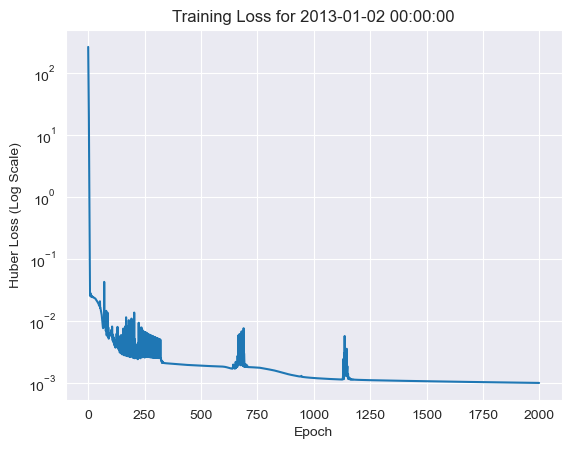

In [13]:
# Example Usage: Pick the first date in your dictionary
target_date = list(moussa_filtered_surface_dict.keys())[0]
target_df = moussa_filtered_surface_dict[target_date]

# Run Training
trained_model, data_proc, losses = fit_surface_for_date(
    date_key=target_date,
    dataframe=target_df,
    epochs=2000,
    lr=0.01
)

# Quick check of convergence
import matplotlib.pyplot as plt
plt.plot(losses)
plt.yscale('log')
plt.title(f"Training Loss for {target_date}")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss (Log Scale)")
plt.show()

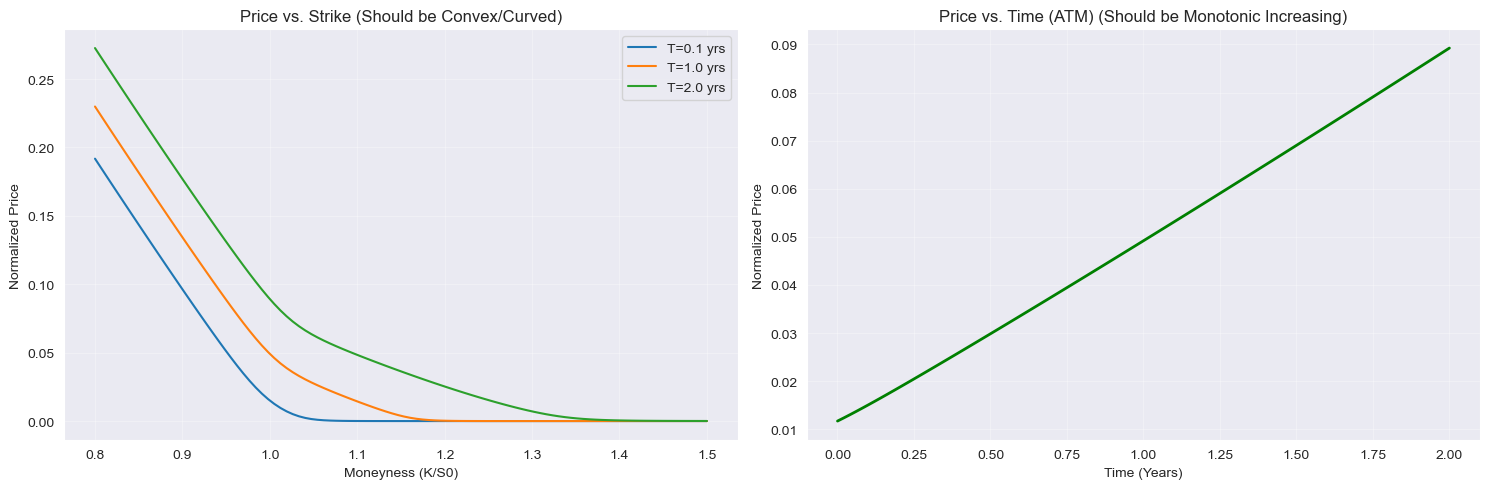


--- Numerical Constraints Verification ---
Total Grid Points Checked: 2500
Time Monotonicity Violations (dC/dT < 0): 0 (0.00%)
Strike Convexity Violations (d2C/dK2 < 0):  0 (0.00%)

✅ PASSED: The surface is strictly arbitrage-free.


In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def sanity_check_model(model, processor):
    model.eval()

    # --- TEST 1: VISUAL SLICES ---
    # We look at 3 distinct maturities to see if the "smile" (price curve) looks right
    maturities_to_plot = [0.1, 1.0, 2.0] # 0.1 years, 1 year, 2 years
    strikes = torch.linspace(0.8, 1.5, 100).reshape(-1, 1) # Moneyness 0.8 to 1.5

    plt.figure(figsize=(15, 5))

    # Subplot 1: Price vs Strike (Convexity Check)
    plt.subplot(1, 2, 1)
    for T_val in maturities_to_plot:
        # Create input batches
        t_input = torch.full_like(strikes, T_val)

        with torch.no_grad():
            # Normalized inputs
            prices = model(strikes, t_input)

        plt.plot(strikes.numpy(), prices.numpy(), label=f'T={T_val} yrs')

    plt.title("Price vs. Strike (Should be Convex/Curved)")
    plt.xlabel("Moneyness (K/S0)")
    plt.ylabel("Normalized Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Price vs Maturity (Monotonicity Check)
    # Pick a specific strike (e.g., At-The-Money K=1.0) and see if price rises with time
    plt.subplot(1, 2, 2)
    times = torch.linspace(0.0, 2.0, 100).reshape(-1, 1)
    k_input = torch.full_like(times, 1.0) # ATM

    with torch.no_grad():
        prices_t = model(k_input, times)

    plt.plot(times.numpy(), prices_t.numpy(), color='green', linewidth=2)
    plt.title("Price vs. Time (ATM) (Should be Monotonic Increasing)")
    plt.xlabel("Time (Years)")
    plt.ylabel("Normalized Price")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- TEST 2: NUMERICAL VIOLATION CHECK ---
    print("\n--- Numerical Constraints Verification ---")

    # Create a dense grid
    grid_k = torch.linspace(0.5, 1.5, 50)
    grid_t = torch.linspace(0.1, 2.0, 50)
    G_k, G_t = torch.meshgrid(grid_k, grid_t, indexing='ij')

    x_flat = G_k.flatten().unsqueeze(1)
    t_flat = G_t.flatten().unsqueeze(1)

    x_flat.requires_grad_(True)
    t_flat.requires_grad_(True)

    # Forward & Derivatives
    price = model(x_flat, t_flat)

    grads = torch.autograd.grad(price, [x_flat, t_flat], torch.ones_like(price), create_graph=True)
    dC_dK = grads[0]
    dC_dT = grads[1]

    d2C_dK2 = torch.autograd.grad(dC_dK, x_flat, torch.ones_like(dC_dK), create_graph=False)[0]

    # 1. Monotonicity Check (dC/dT >= 0)
    # We allow a tiny epsilon for floating point errors (-1e-6)
    time_violations = (dC_dT < -1e-6).sum().item()
    total_points = x_flat.shape[0]

    # 2. Convexity Check (d2C/dK2 >= 0)
    convex_violations = (d2C_dK2 < -1e-6).sum().item()

    print(f"Total Grid Points Checked: {total_points}")
    print(f"Time Monotonicity Violations (dC/dT < 0): {time_violations} ({time_violations/total_points:.2%})")
    print(f"Strike Convexity Violations (d2C/dK2 < 0):  {convex_violations} ({convex_violations/total_points:.2%})")

    if time_violations == 0 and convex_violations == 0:
        print("\n✅ PASSED: The surface is strictly arbitrage-free.")
        return True
    else:
        print("\n⚠️ WARNING: Minor numerical violations detected.")
        return False

# Run the check
is_valid = sanity_check_model(trained_model, data_proc)

In [19]:
import torch
import numpy as np
import plotly.graph_objects as go

def plot_isnn_surface_interactive(model, processor, dataframe, resolution=60):
    """
    Plots an interactive 3D surface of the ISNN model using Plotly.

    Args:
        model: The trained ISNN2_OptionSurface model.
        processor: The OptionSurfaceData instance (contains 'spot' for normalization).
        dataframe: The Pandas DataFrame containing the raw data (for scatter plot).
        resolution: Grid density (higher = smoother surface).
    """
    model.eval()
    device = next(model.parameters()).device

    # --- 1. PREPARE GRID (Real World Units) ---
    # Determine bounds from data
    k_min, k_max = dataframe['strike'].min(), dataframe['strike'].max()
    t_min, t_max = dataframe['maturity_days'].min(), dataframe['maturity_days'].max()

    # Create linear spaces (add slight buffer of 5% on edges)
    strikes_real = np.linspace(k_min * 0.95, k_max * 1.05, resolution)
    times_real   = np.linspace(t_min * 0.95, t_max * 1.05, resolution)

    # Create Meshgrid
    K_mesh, T_mesh = np.meshgrid(strikes_real, times_real)

    # Flatten for batch processing
    k_flat = K_mesh.flatten()
    t_flat = T_mesh.flatten()

    # --- 2. NORMALIZE (Match Training Logic) ---
    # K_norm = Strike / Spot
    # T_norm = Days / 365
    spot_ref = processor.spot

    k_norm = k_flat / spot_ref
    t_norm = t_flat / 365.0

    # Convert to Tensor
    x_tensor = torch.tensor(k_norm, dtype=torch.float32).view(-1, 1).to(device)
    t_tensor = torch.tensor(t_norm, dtype=torch.float32).view(-1, 1).to(device)

    # --- 3. INFERENCE ---
    with torch.no_grad():
        # Model returns Normalized Price (Price / Spot)
        price_pred_norm = model(x_tensor, t_tensor).cpu().numpy().flatten()

    # --- 4. DENORMALIZE OUTPUT ---
    # Price = C_norm * Spot
    price_pred = price_pred_norm * spot_ref

    # Reshape for Plotly
    Z_mesh = price_pred.reshape(K_mesh.shape)

    # --- 5. PLOTLY VISUALIZATION ---
    fig = go.Figure()

    # A. The Neural Network Surface
    fig.add_trace(go.Surface(
        z=Z_mesh,
        x=K_mesh,
        y=T_mesh,
        colorscale='Viridis',
        opacity=0.8,
        name='ISNN Surface',
        colorbar=dict(title='Price', x=0) # Move colorbar to left
    ))

    # B. The Actual Training Data (Red Dots)
    # This helps you visually check if the model fits the points well
    fig.add_trace(go.Scatter3d(
        x=dataframe['strike'],
        y=dataframe['maturity_days'],
        z=dataframe['moussa_price'],
        mode='markers',
        marker=dict(
            size=3,
            color='red',
            symbol='circle',
            opacity=0.9
        ),
        name='Moussa Data'
    ))

    # C. Layout & Aesthetics
    fig.update_layout(
        title=f'ISNN Implied Volatility Surface (Spot: {spot_ref:.2f})',
        scene=dict(
            xaxis_title='Strike Price (K)',
            yaxis_title='Time to Maturity (Days)',
            zaxis_title='Option Price ($)',
            xaxis=dict(backgroundcolor="rgb(230, 230,230)"),
            yaxis=dict(backgroundcolor="rgb(230, 230,230)"),
            zaxis=dict(backgroundcolor="rgb(230, 230,230)"),
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=0.6) # Flatten z-axis slightly for better view
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        width=900,
        height=700
    )

    fig.show()

# --- EXECUTE ---
# Assuming 'trained_model', 'data_proc', and 'target_df' are already in memory
plot_isnn_surface_interactive(trained_model, data_proc, target_df)